# pysystemtrade 交互式学习笔记

> 跟随 `docs/introduction.md` 与 `examples/introduction/` 的路径，通过实际运行代码重新吃透这个项目。

**核心公式：一个交易系统 = 数据 (data) + 若干处理阶段 (stages) + 配置 (config)**

```mermaid
flowchart LR
    A[原始数据 data] --> B[Rules 交易规则]
    B --> C[ForecastScaleCap 缩放/截顶]
    C --> D[ForecastCombine 预测组合]
    D --> E[PositionSizing 头寸规模]
    E --> F[Portfolios 组合构建]
    F --> G[Account 盈亏核算]
    H[Config YAML/dict] -.控制各阶段行为.-> B
    H -.-> C
    H -.-> D
    H -.-> E
    H -.-> F
```

**三个关键设计模式（贯穿全项目）：**
1. **阶段名固定**：无论类/实例叫什么，访问永远是 `system.rules`、`system.combForecast`、`system.positionSize` 等
2. **TradingRule 三要素**：`function` + `data`（类似 *args）+ `other_args`（类似 **kwargs）
3. **Config 驱动**：生产环境用 YAML 配置控制系统行为，而不是散落在脚本里

注意：你看到的结果会与文档中略有不同，因为 CSV 数据已更新到更近的日期。

# 我的理解

## 系统构成
系统 = 数据 + 规则 + 配置？这个公式我总是记不住，因为我理解上有问题。data + config这两项没有歧义，但我总是想不起stage这个概念，而是想到rule/forcast。

## 系统状态机
规则只是一小部分。数据是系统的输入，配置是系统的控制器，stage是系统处理输入的流水线/状态机。从输入到输出，输入的是数据，最终输出的是账户的PnL，中间产物是由各层次算法对上一层次输出的处理/变形。

## 系统工况与输入可变性
对于系统运行状态，stage，系统固定流程；data，系统的可变输入项；config，系统的固定输入项。而对于系统测试状态，data是固定的测试样本，config则是可变的被测试规则。

## 系统构成的另一种理解
那么更一般的模型就是数据+程序，阶段则是对数据+程序在不同环节中的描述。

## 串行工作流
更一般化的理解，当前系统是串行的，因为下一个阶段依赖于上一个阶段，是有向无环的，在系统运行阶段总是这样线性逻辑。而在系统优化阶段，则会出现根据后续阶段的输出反过来调整先前阶段的参数设置。

## 并行工作流
也许一些系统的形态会是并行式的，即各个阶段同时处理数据+配置，输出再以某种方式合成。
“合成”这个词指向了combine，表明了在forcast阶段是存在并行工作流的。

## 系统阶段组成
阶段是一条pipeline/逻辑链。

### 预测 forcast
首先是数据，特定品种的行情数据，与config中的forcast结合。即forcast = data + rule = instrument + rules，例如corn + ewmac，或者更具体的corn + ewmac4,16 + ewmac8,32。
这表明了一个品种可以搭配多个预测规则。这就是前文提到的并行。combine就涉及权重，一般使用等权。另外combine就是组合，有组合就有分散，这就引出了系统化交易的第一个edge/bonus，大于1的预测分散化乘数FDM。但combine在carver体系中似乎特指交易工具组合，那么forcast就是对rule的隐式组合。

### 预测的缩放和封顶 forcastScalarCap
预测是一个无量纲的数值，不同预测所在的数值范围差异很大，需要通过类似于归一化的操作使数值可比，也就是通过缩放系数scalar，将预测值映射到[-20,20]的区间中。按照carver的预设强度分级，10相当于标准做多，5相当于半仓做多，20相当于2倍做多。而且他拒绝采用超过20的数值，这就是封顶cap。

#### 组合与缩放
一个困惑点在于，先组合还是先缩放。稍加思考可以认为，组合和缩放是配对关系，组合需要确定成分的权重，因此一次组合必然需要一次缩放调整权重，并且是先缩放再组合，避免数值范围大的在组合中占据不合理的过高权重。
forcast -> forcast_scalar -> combine -> FDM
由于系统中实际上涉及了预测内的规则之间的隐式组合和预测之间的显式组合，因此scalar也能进一步特化为ruleScalar和forcastScalar吗？事实上ruleScalar并不存在，rule是等权重的，因为carver表示并不存在充分证据表明一种预测规则明显优于另一种。因此在等权重的假设下，系统中并不需要ruleScalar。

### 预测组合 forcastCombine
后续思考速度变慢，或者先让AI介入。
forcasts -> forcast_scalar -> forcast_weight -> combine -> FDM
instruments -> instrument_weight -> portfolio -> IDM
分散化乘数的作用是什么？由于combine或portfolio是归一化的，但其中的成分具有低相关性，因此当combine和portfolio名义上达到1时，实际强度是不足1的，因此需要分散化乘数对组合进行等比例放大，使组合的实际强度达到1。
因此forcast_scalar和forast diversification multipler是对偶的，作用是对每一个forcast的数值范围进行适当的调整。
而scalar与weight也存在对偶关系，由于weight是portfolio中的工具权重，scalar相当于combine中的预测权重。

# 题眼（再生用）

> 不记结论，只记能重新推导出结论的入口。每条给出最小实验或对照物——看到 → 想问 → 动手试，理解自然会再生。

- **scalar vs weight**：同一 config 里并存 `forecast_scalars=dict(ewmac8=5.3)` 和 `forecast_weights=dict(ewmac8=0.5)`。问：把 weight 改成 (0.9, 0.1)，combined 怎么变？把 scalar 翻倍呢？两者改变的对象不同。
- **stage 是算子**：对照三个方法名——`get_raw_forecast` / `get_capped_forecast` / `get_combined_forecast`。同一个词 forecast，三个对象。维度 (instrument × rule × time) 在哪一步被压缩？
- **拉取式求值**：开 DEBUG 日志，只调 `get_combined_forecast("SOFR")`。看日志里计算的触发顺序——是顺流而下还是逆流而上？由此理解为什么需要 cache。
- **instrument 是接口**：对照 `get_subsystem_position`（抽象信号单位）和 `get_notional_position`（合约名义价值）的输出单位。哪一层可以直接翻译成"买 3 手 CORN"？
- **降维次序的物理约束**：设想一个假想 stage 先压缩 instrument 维度再 sizing——下单时还剩下什么信息？
- **加法/复利口径分叉**：同一收益序列，`cumsum` vs `cumprod`。问：vol target 翻倍，Sharpe 变吗？复利 CAGR 翻倍吗？两口径的裂口 = 波动税 $\sigma^2/2$，随杠杆**平方**增长，而收益只线性增长 → 最优杠杆 $k^* = \mu/\sigma^2$（Kelly）。用途分工：策略评估用加法口径（隔离杠杆，比率对杠杆免疫），仓位决策用复利口径（杠杆有代价，存在最优点）。§12 实验：vt=15/25/50 三组 NAV 对比。


<a id="map"></a>
# 概念地图（可跳转）

> 按概念依赖组织，不按页码。每个节点可点击跳到对应小节；先挑你最有问题感的节点进。

```mermaid
flowchart TD
    S1["§1 数据与元数据"] --> S2["§2 价格与 carry"]
    S2 --> S3["§3 手动 EWMAC"]
    S3 --> S4["§4 单规则盈亏"]
    S3 --> S5["§5 最小系统 Rules+System"]
    S5 --> S6["§6 TradingRule 三要素"]
    S6 --> S7["§7 Config/YAML"]
    S7 --> S8["§8 ForecastScaleCap"]
    S8 --> S9["§9 ForecastCombine + FDM"]
    S9 --> S10["§10 PositionSizing"]
    S10 --> S11["§11 Portfolios + IDM"]
    S11 --> S12["§12 Account 盈亏核算"]
    S12 --> S13["§13 预烘焙系统"]
    S13 --> S14["§14 缓存"]
    MY["我的理解 / 题眼"] -.贯穿提问.-> S8
    MY -.-> S9
```

| 我想搞懂… | 去这里 |
|---|---|
| 数据从哪来、怎么换成 IB | [§1](#s1), [§2](#s2) |
| 一条规则怎么变成钱 | [§3](#s3) → [§4](#s4) |
| System/stage 到底是什么 | [§5](#s5) → [§7](#s7) |
| scalar、cap、±20 | [§8](#s8) |
| 权重、FDM、为什么要组合 | [§9](#s9) |
| 波动目标怎么定仓位 | [§10](#s10) |
| IDM、品种间分散 | [§11](#s11) |
| 成本、净/毛收益 | [§12](#s12) |
| 生产里实际怎么建系统 | [§13](#s13) |
| 算得慢怎么办 | [§14](#s14) |

**分叉提示**：§5–§7 是机制层（怎么组装），§8–§12 是算法层（每站做什么）。机制卡住回 [§5](#s5)，直觉卡住回 [§3](#s3)。


# Concept Map

System = Data + Stages + Config

Data, rawPrice, rawForcast
<a>Map</a>

<a id="s1"></a>
## 1. 加载模拟数据与探索合约信息

`data` 对象是整个系统的数据源。这里使用预烘焙的 CSV 数据 `csvFuturesSimData`。

**继承链**：`csvFuturesSimData`（数据特定）→ `FuturesSimData`（资产类别特定）→ `simData`（通用）。以后换成 IB 实时数据时，只需替换最左端的类，上层逻辑完全不变。

[↑ 回概念地图](#map)


In [6]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData

data = csvFuturesSimData()
print(data)
print(data.get_instrument_list())

csvFuturesSimData object with 253 instruments
['AEX', 'AEX_mini', 'ALUMINIUM', 'ALUMINIUM_LME', 'AUD', 'AUDJPY', 'AUD_micro', 'BB3M', 'BBCOMM', 'BITCOIN', 'BOBL', 'BONO', 'BOVESPA', 'BRE', 'BRENT-LAST', 'BRENT_W', 'BTP', 'BTP3', 'BUND', 'BUTTER', 'BUXL', 'CAC', 'CAD', 'CAD10', 'CAD2', 'CAD5', 'CAD_micro', 'CANOLA', 'CH10', 'CHEESE', 'CHF', 'CHFJPY', 'CHF_micro', 'CHINAA-CON', 'CLP', 'CNH-onshore', 'CNH', 'COAL-GEORDIE', 'COAL', 'COCOA', 'COCOA_LDN', 'COFFEE', 'COPPER-micro', 'COPPER-mini', 'COPPER', 'COPPER_LME', 'CORN', 'CORN_mini', 'COTTON', 'COTTON2', 'CRUDE_ICE', 'CRUDE_W', 'CRUDE_W_micro', 'CRUDE_W_mini', 'CZK', 'DAX', 'DJSTX-SMALL', 'DOW', 'DOW_mini', 'DX', 'EDOLLAR', 'EPRA-EUROPE', 'ETHANOL', 'ETHER-micro', 'ETHEREUM', 'EU-AUTO', 'EU-BANKS', 'EU-BASIC', 'EU-CHEM', 'EU-CONSTRUCTION', 'EU-DIV30', 'EU-DJ-OIL', 'EU-DJ-TECH', 'EU-DJ-TELECOM', 'EU-DJ-UTIL', 'EU-FOOD', 'EU-HEALTH', 'EU-HOUSE', 'EU-INSURE', 'EU-MEDIA', 'EU-MID', 'EU-OIL', 'EU-REALESTATE', 'EU-RETAIL', 'EU-TECH', 'EU-TRA

In [7]:
# 合约元数据：点值、币种、资产类别、滑点、佣金假设
# 这些信息在之后的头寸规模和成本计算中都会用到
data.get_instrument_object_with_meta_data("MUMMY")

futuresInstrumentWithMetaData(instrument=MUMMY, meta_data={'Description': 'TSE Mothers Index', 'Pointsize': 1000.0, 'Currency': 'JPY', 'AssetClass': 'Equity', 'PerBlock': 50.0, 'Percentage': 0.0, 'PerTrade': 0, 'Region': 'ASIA'})

In [8]:
# carry 数据四列含义：
#   PRICE          远月合约的拼接价格（用于定价当前头寸）
#   CARRY          近月合约价格（用于计算 carry 价差）
#   PRICE_CONTRACT 远月合约月份（如 202612 = 2026年12月）
#   CARRY_CONTRACT 近月合约月份（如 202609 = 2026年9月）
# carry 信号 = f(CARRY - PRICE) 或反过来，取决于品种约定
data.get_instrument_raw_carry_data("SOFR").tail(6)

,PRICE,CARRY,PRICE_CONTRACT,CARRY_CONTRACT
index,,,,
2024-03-28 16:00:00,96.425,96.405,20261200,20260900
2024-03-28 17:00:00,96.415,96.395,20261200,20260900
2024-03-28 18:00:00,96.415,96.395,20261200,20260900
2024-03-28 19:00:00,96.410,96.390,20261200,20260900
2024-03-28 20:00:00,96.405,96.385,20261200,20260900
2024-03-28 23:00:00,96.405,96.390,20261200,20260900


<a id="s2"></a>
## 2. 获取价格与 Carry 数据

`get_raw_price()` 返回的是**回调整合 (back-adjusted) 价格**——用 panama 方法把相邻合约拼接起来的连续价格序列，而不是某个真实合约的价格。原因：

- 真实合约价格在不同合约间有跳变，用它算波动率会失真
- 拼接价格能捕捉**展期收益 (rolldown)**，参考 [Rob 的博客](https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html)

期货特有的另一类数据是 **carry 数据**（实现 carry 规则所需）：

[↑ 回概念地图](#map)


In [9]:
data.get_raw_price("SOFR").tail(5)

index
2024-03-28 17:00:00    96.415
2024-03-28 18:00:00    96.415
2024-03-28 19:00:00    96.410
2024-03-28 20:00:00    96.405
2024-03-28 23:00:00    96.405
Name: price, dtype: float64

In [10]:
# 遍历所有品种，找出哪些品种的 carry_contract 是近月（price_contract 是远月）
# 这些品种与"carry 是远月"的直觉相反，值得关注
unusual_carry = []
for instrument in data.get_instrument_list():
    try:
        carry = data.get_instrument_raw_carry_data(instrument)
        latest = carry.iloc[-1]
        price_ym = int(latest['PRICE_CONTRACT']) // 100
        carry_ym = int(latest['CARRY_CONTRACT']) // 100
        if price_ym > carry_ym:  # price 是远月，carry 是近月
            unusual_carry.append((instrument, price_ym, carry_ym))
    except:
        pass

print(f"共找到 {len(unusual_carry)} 个品种 carry 是近月：\n")
for instrument, price_ym, carry_ym in unusual_carry:
    print(f"{instrument:20s} PRICE:{price_ym} CARRY:{carry_ym}")

共找到 58 个品种 carry 是近月：

BB3M                 PRICE:202406 CARRY:202403
BRENT-LAST           PRICE:202407 CARRY:202406
BRENT_W              PRICE:202408 CARRY:202407
BUTTER               PRICE:202405 CARRY:202404
CANOLA               PRICE:202407 CARRY:202405
CHEESE               PRICE:202405 CARRY:202404
COAL-GEORDIE         PRICE:202405 CARRY:202404
COAL                 PRICE:202404 CARRY:202403
COCOA                PRICE:202407 CARRY:202405
COCOA_LDN            PRICE:202407 CARRY:202405
COFFEE               PRICE:202407 CARRY:202405
CORN                 PRICE:202412 CARRY:202409
COTTON2              PRICE:202407 CARRY:202405
CRUDE_W              PRICE:202412 CARRY:202411
CRUDE_W_micro        PRICE:202407 CARRY:202406
CRUDE_W_mini         PRICE:202406 CARRY:202405
EDOLLAR              PRICE:202612 CARRY:202609
EUA                  PRICE:202512 CARRY:202509
EURIBOR-ICE          PRICE:202606 CARRY:202603
EURIBOR              PRICE:202606 CARRY:202603
FED                  PRICE:202410 CAR

In [11]:
# 观察更多品种carry数据的特点
# ALUMINIUM，应该是商品铝，符合一般讨论上的carry结构，即price_contract是近月，carry_contract是远月，远月合约价格更高，呈升水状态。
# WHEAT，应该是商品小麦，远月合约价格更高，呈升水状态。但price_contract是远月，carry_contract是近月，感到奇怪。
data.get_instrument_raw_carry_data("WHEAT").tail(6)

,PRICE,CARRY,PRICE_CONTRACT,CARRY_CONTRACT
index,,,,
2024-03-28 14:00:00,604.50,581.00,20241200,20240900
2024-03-28 15:00:00,607.75,585.50,20241200,20240900
2024-03-28 16:00:00,615.00,595.00,20241200,20240900
2024-03-28 17:00:00,610.75,590.25,20241200,20240900
2024-03-28 18:00:00,613.25,593.00,20241200,20240900
2024-03-28 23:00:00,612.00,591.50,20241200,20240900


In [12]:
# 遍历所有合约，检查单个合约中carry是近月还是远月的关系是固定的还是会变化的
# 注意：合约列读入时是字符串（如 "20261200"），需先转 int 才能做 //
results = []
for instrument in data.get_instrument_list():
    try:
        carry = data.get_instrument_raw_carry_data(instrument)
        price_ym = carry['PRICE_CONTRACT'].astype(int) // 100
        carry_ym = carry['CARRY_CONTRACT'].astype(int) // 100
        # price_ym > carry_ym 意味着 price 远月 / carry 近月（"反常"）
        ratio = (price_ym > carry_ym).mean()  # "反常"行占总行数的比例
        results.append((instrument, ratio, len(carry)))
    except Exception as e:
        print(f"[跳过] {instrument}: {type(e).__name__}: {e}")

import pandas as pd
df = pd.DataFrame(results, columns=['instrument', 'unusual_ratio', 'n_rows']).set_index('instrument')

always_far_carry = df[df.unusual_ratio == 0]          # carry 永远是远月
always_near_carry = df[df.unusual_ratio == 1]         # carry 永远是近月
switching = df[(df.unusual_ratio > 0) & (df.unusual_ratio < 1)]  # 关系会变化

print(f"carry 永远是远月: {len(always_far_carry)} 个品种")
print(f"carry 永远是近月: {len(always_near_carry)} 个品种 -> {list(always_near_carry.index)}")
print(f"关系会切换的:   {len(switching)} 个品种")
print()
print(switching.sort_values('unusual_ratio', ascending=False))

carry 永远是远月: 194 个品种
carry 永远是近月: 56 个品种 -> ['BB3M', 'BRENT-LAST', 'BRENT_W', 'BUTTER', 'CANOLA', 'CHEESE', 'COAL-GEORDIE', 'COAL', 'COCOA', 'COCOA_LDN', 'COFFEE', 'CORN', 'COTTON2', 'CRUDE_W', 'CRUDE_W_micro', 'CRUDE_W_mini', 'EDOLLAR', 'EUA', 'EURIBOR-ICE', 'EURIBOR', 'FED', 'FEEDCOW', 'GAS-LAST', 'GAS-PEN', 'GASOIL', 'GASOILINE', 'HEATOIL', 'IRON', 'LEANHOG', 'LIVECOW', 'MILK', 'MILKDRY', 'MILKWET', 'MILLWHEAT', 'OATIES', 'REDWHEAT', 'RICE', 'ROBUSTA', 'SARONA', 'SILVER', 'SOFR', 'SONIA3', 'SOYBEAN', 'SOYMEAL', 'SOYOIL', 'STEEL', 'SUGAR11', 'SUGAR16', 'SUGAR_WHITE', 'V2X', 'VIX', 'VIX_mini', 'VNKI', 'WHEAT', 'WHEAT_ICE', 'WHEY']
关系会切换的:   3 个品种

             unusual_ratio  n_rows
instrument                        
GAS_US_mini       0.997559   30728
GAS_US            0.963303   59105
GICS              0.007583   22682


<a id="s3"></a>
## 3. 手动实现 EWMAC 交易规则

**EWMAC**（Exponentially Weighted Moving Average Crossover）是全书最经典的趋势规则：

$$\text{forecast} = \frac{\text{EWMA}_{\text{fast}}(P) - \text{EWMA}_{\text{slow}}(P)}{\sigma(\Delta P)}$$

- 分子：快慢指数均线之差 → 趋势方向与强度
- 分母：波动率归一化 → 让不同波动率的品种产生的信号可比较

**关键点**：必须用拼接价格（而不是实际交易合约的价格），否则合约切换时波动率会跳变，且会丢失展期收益。

[↑ 回概念地图](#map)


In [13]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    计算 EWMAC 交易规则的预测值。

    price: 拼接后的价格序列（back-adjusted）
    Lfast: 快 EWMA 的 span；Lslow 缺省为 4 * Lfast
    """
    price = price.resample("1B").last()  # 重采样到工作日，取最后一个价
    if Lslow is None:
        Lslow = 4 * Lfast

    # 直接用 span，无需算衰减参数
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())  # 稳健波动率（指数加权，抗离群值）
    return raw_ewmac / vol

3.037728459460719
-13.87284956552481
12.634299726791495
index
2024-03-22    1.820182
2024-03-25    1.925310
2024-03-26    2.023696
2024-03-27    2.132803
2024-03-28    2.238096
Freq: B, Name: price, dtype: float64


<Axes: title={'center': 'EWMAC(32,128) forecast - COPPER'}, xlabel='index'>

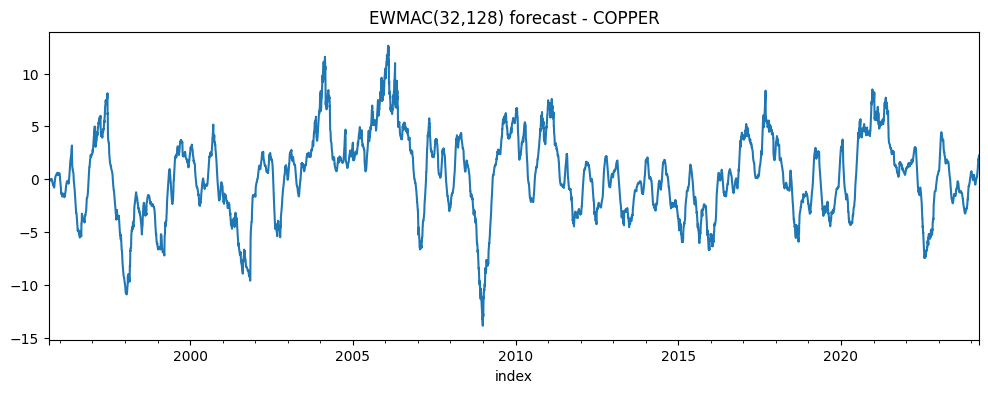

In [14]:
%matplotlib inline

instrument_code = "COPPER"
price = data.daily_prices(instrument_code)
ewmac = calc_ewmac_forecast(price, 32, 128)

print(ewmac.abs().mean())
print(ewmac.min())
print(ewmac.max())
print(ewmac.tail(5))
ewmac.plot(figsize=(12, 4), title=f"EWMAC(32,128) forecast - {instrument_code}")

<a id="s4"></a>
## 4. 单规则盈亏分析（account_forecast）

`pandl_for_instrument_forecast` 把 forecast 直接当作头寸来结算盈亏（此处不含成本、未做缩放）。

返回的 `account` 对象**继承自 pandas DataFrame**，并附加了大量统计方法（`syscore.pandas.strategy_functions` 中定义）。

重点指标速查：
- `sharpe`：年化夏普比率
- `calmar`：年化收益 / 最大回撤类指标
- `hitrate`：胜率
- `t_stat` / `p_value`：统计显著性

[↑ 回概念地图](#map)


In [15]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast

account = pandl_for_instrument_forecast(forecast=ewmac, price=price)
account.percent.stats()

[[('min', '-4.376'),
  ('max', '5.059'),
  ('median', '0'),
  ('mean', '0.009098'),
  ('std', '0.4296'),
  ('skew', '0.09482'),
  ('ann_mean', '2.329'),
  ('ann_std', '6.873'),
  ('sharpe', '0.3389'),
  ('sortino', '0.4075'),
  ('avg_drawdown', '-10.77'),
  ('time_in_drawdown', '0.985'),
  ('calmar', '0.09178'),
  ('avg_return_to_drawdown', '0.2162'),
  ('avg_loss', '-0.2454'),
  ('avg_gain', '0.2635'),
  ('gaintolossratio', '1.074'),
  ('profitfactor', '1.079'),
  ('hitrate', '0.5011'),
  ('t_stat', '1.829'),
  ('p_value', '0.06747')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

年化夏普: 0.3388934645625955


<Axes: title={'center': 'Drawdown (%)'}, xlabel='index'>

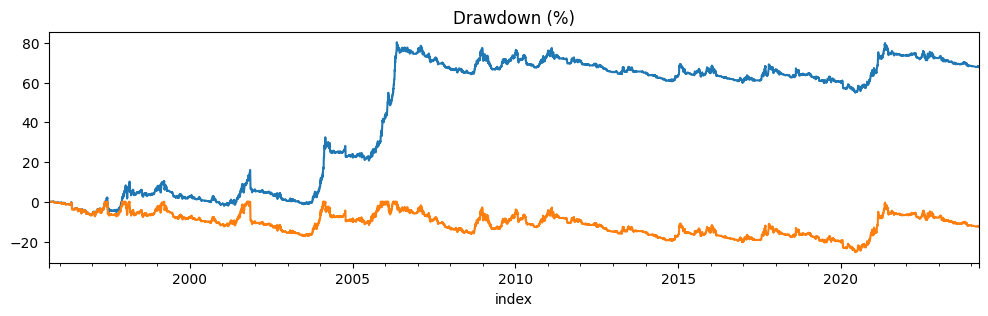

In [16]:
import syscore.pandas.strategy_functions  # 注册 .sharpe() 等扩展方法

print("年化夏普:", account.sharpe())
account.curve().plot(figsize=(12, 4), title="Cumulative % curve")   # 累计净值曲线
account.drawdown().plot(figsize=(12, 3), title="Drawdown (%)")      # 回撤曲线
# 其他可用：account.percent / account.weekly / account.monthly / account.gross.ann_mean()

<a id="s5"></a>
## 5. 构建最小系统：Rules + System

单个脚本能做的有限。真正的威力在于**系统 (System)**：由 data + 若干 stage + 可选 config 组成。

完整阶段流水线：
1. RawData（原始数据预处理）
2. Rules（交易规则 → 原始预测）
3. ForecastScaleCap（缩放 + 截顶）
4. ForecastCombine（多规则组合）
5. PositionSizing（头寸规模）
6. Portfolios（组合构建）
7. Account（盈亏核算）

先用最简单的系统——只有一个 Rules 阶段。注意使用项目内置的 `ewmac_forecast_with_defaults`（带默认参数版本）。

[↑ 回概念地图](#map)


In [17]:
from systems.provided.rules.ewmac import ewmac_forecast_with_defaults as ewmac
from systems.forecasting import Rules
from systems.basesystem import System

# 方式一：直接传函数，规则自动命名为 rule0（不好认）
my_rules = Rules(ewmac)
print(my_rules.trading_rules())

# 方式二：传 dict，规则名一目了然
my_rules = Rules(dict(ewmac=ewmac))
print(my_rules.trading_rules())

{'rule0': TradingRule; function: <function ewmac_forecast_with_defaults at 0x00000149C10BC360>, data: data.daily_prices (args: {}) and other_args: }
{'ewmac': TradingRule; function: <function ewmac_forecast_with_defaults at 0x00000149C10BC360>, data: data.daily_prices (args: {}) and other_args: }


In [18]:
my_system = System([my_rules], data)
print(my_system)

# 通用模式：system.<stage名>.get_something(...)
# 结果与第 3 节手动计算完全一致——但现在有了可扩展的框架
my_system.rules.get_raw_forecast("SOFR", "ewmac").tail(5)

System base_system with .config, .data, and .stages: rules
2026-09-14 22:44:09 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:09 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:09 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:09 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac


index
2024-03-22   -0.349853
2024-03-25   -0.378965
2024-03-26   -0.394422
2024-03-27   -0.381021
2024-03-28   -0.378662
Freq: B, Name: price, dtype: float64

<a id="s6"></a>
## 6. TradingRule 的多种定义方式与多规则变体

一个 `TradingRule` 包含 3 个元素：
- `function`：规则函数
- `data`：函数需要的数据列表（类似 *args，缺省时默认传日价格）
- `other_args`：其余参数 dict（类似 **kwargs）

**三种等价定义方式**：直接传函数 / 三元组 tuple / dict。用不同参数定义同一个规则的多个"风味"：

[↑ 回概念地图](#map)


In [19]:
from systems.trading_rules import TradingRule

ewmac_rule = TradingRule(ewmac)                                        # 最简形式
ewmac_8 = TradingRule((ewmac, [], dict(Lfast=8, Lslow=32)))            # tuple 形式
ewmac_32 = TradingRule(dict(function=ewmac,
                            other_args=dict(Lfast=32, Lslow=128)))     # dict 形式
print(ewmac_32)

my_rules = Rules(dict(ewmac8=ewmac_8, ewmac32=ewmac_32))
my_system = System([my_rules], data)

# ewmac32 参数等于默认值，结果应与第 5 节一致
my_system.rules.get_raw_forecast("SOFR", "ewmac32").tail(5)

TradingRule; function: <function ewmac_forecast_with_defaults at 0x00000149C10BC360>, data: data.daily_prices (args: {}) and other_args: Lfast, Lslow
2026-09-14 22:44:10 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:10 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:10 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:10 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac32


index
2024-03-22   -0.349853
2024-03-25   -0.378965
2024-03-26   -0.394422
2024-03-27   -0.381021
2024-03-28   -0.378662
Freq: B, Name: price, dtype: float64

<a id="s7"></a>
## 7. Config 配置对象与 YAML 加载

**Config** 是控制各阶段行为的核心。三种创建方式：
1. `Config()` 空对象，之后逐个设属性
2. `Config(dict(...))` 从字典
3. `Config("systems.provided.example.simplesystemconfig.yaml")` 从 YAML（Python 风格路径引用，不写文件名）

**YAML 中的关键机制**：函数和数据源都用**字符串路径**指定（如 `systems.provided.rules.ewmac.ewmac_forecast_with_defaults`、`data.daily_prices`），系统启动时解析。这样纯文本配置就能完整描述一个系统。

[↑ 回概念地图](#map)


In [20]:
from sysdata.config.configdata import Config

# 方式一：空 Config + 属性注入。注意这里 Rules() 是空实例，规则由 config 提供
my_config = Config()
empty_rules = Rules()
my_config.trading_rules = dict(ewmac8=ewmac_8, ewmac32=ewmac_32)
my_system = System([empty_rules], data, my_config)
print(my_system.rules.get_raw_forecast("SOFR", "ewmac8").tail(3))

# 注意：如果同时把规则传给 Rules() 构造器和 config，只有前者生效

2026-09-14 22:44:10 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:10 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:10 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:10 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac8
index
2024-03-26   -0.648340
2024-03-27   -0.476329
2024-03-28   -0.381107
Freq: B, Name: price, dtype: float64


In [21]:
# 方式三：从 YAML 文件加载（生产环境的标准做法）
yaml_config = Config("systems.provided.example.simplesystemconfig.yaml")
print(yaml_config)

# 对照打开 systems/provided/example/simplesystemconfig.yaml 查看：
# trading rule 的 function 是字符串路径；ewmac8 显式指定了 data: data.daily_prices（即默认值）

Config with elements: base_currency, forecast_div_multiplier, forecast_weights, instrument_div_multiplier, instrument_weights, notional_trading_capital, percentage_vol_target, trading_rules


<a id="s8"></a>
## 8. 预测缩放与截断（ForecastScaleCap）

原始 EWMAC 预测没有统一量纲。目标：**平均绝对值 = 10**，并**截顶到 ±20**（防止极端信号支配仓位）。

两种方式得到缩放因子 (forecast scalar)：
- **滚动样本外估计**：`use_forecast_scale_estimates=True`（默认跨品种池化估计，更稳健）
- **固定值**：`forecast_scalars=dict(...)`（可用书中附录 B 的经验值）

注意：传入 `System([...])` 的阶段列表**顺序无关**。

[↑ 回概念地图](#map)


In [22]:
from systems.forecast_scale_cap import ForecastScaleCap

fcs = ForecastScaleCap()

# 方式一：滚动样本外估计（跨品种池化）
my_config.instruments = ["SOFR", "US10", "CORN", "SP500_micro"]
my_config.use_forecast_scale_estimates = True

my_system = System([fcs, my_rules], data, my_config)
print(my_system.forecastScaleCap.get_forecast_scalar("SOFR", "ewmac32").tail(5))

2026-09-14 22:44:10 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:10 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:10 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:10 DEBUG base_system {'stage': 'forecastScaleCap'} Getting cross sectional forecasts for scalar calculation for ewmac32 over CORN, SOFR, SP500_micro, US10
2026-09-14 22:44:10 DEBUG base_system {'stage': 'rules', 'instrument_code': 'CORN'} Calculating raw forecast CORN for ewmac32
2026-09-14 22:44:10 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac32
2026-09-14 22:44:11 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500_micro'} Calculating raw forecast SP500_micro for ewmac32
2026-09-14 22:44:11 DEBUG base_system {'stage': 'rules', 'instrument_

In [23]:
# 方式二：固定缩放因子（书中附录 B 的经验值）
my_config.forecast_scalars = dict(ewmac8=5.3, ewmac32=2.65)
my_config.use_forecast_scale_estimates = False

my_system = System([fcs, empty_rules], data, my_config)
print("scalar:", my_system.forecastScaleCap.get_forecast_scalar("SOFR", "ewmac32"))

# 截顶后的预测（默认 cap=20，定义在系统默认值文件）
my_system.forecastScaleCap.get_capped_forecast("SOFR", "ewmac32").tail(5)

2026-09-14 22:44:11 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:11 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:11 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:11 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac32
scalar: index
1984-03-23    2.65
1984-03-26    2.65
1984-03-27    2.65
1984-03-28    2.65
1984-03-29    2.65
              ... 
2024-03-22    2.65
2024-03-25    2.65
2024-03-26    2.65
2024-03-27    2.65
2024-03-28    2.65
Freq: B, Length: 10440, dtype: float64
2026-09-14 22:44:11 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SOFR'} Calculating capped forecast for SOFR ewmac32


index
2024-03-22   -0.927110
2024-03-25   -1.004257
2024-03-26   -1.045217
2024-03-27   -1.009705
2024-03-28   -1.003454
Freq: B, dtype: float64

<a id="s9"></a>
## 9. 预测组合与多样化乘数（ForecastCombine）

多个规则变体需要组合。组合预测公式：

$$\text{combined} = \text{FDM} \times \sum_i w_i \cdot \text{forecast}_i$$

- $w_i$：预测权重 (forecast weights)
- **FDM**（forecast diversification multiplier）：多样化乘数，补偿权重分散造成的信号强度损失

三种方式：默认等权 + FDM=1（会打 WARNING）/ 滚动估计 / 固定值。

> **估计权重时需要 Account 阶段**：因为权重估计依赖各规则的历史表现，而历史表现需要 PositionSizing 和 RawData 才能算出来。这体现了阶段间的依赖关系。

[↑ 回概念地图](#map)


In [24]:
from systems.forecast_combine import ForecastCombine

combiner = ForecastCombine()
my_system = System([fcs, empty_rules, combiner], data, my_config)

# 未配置权重时：等权 0.5/0.5 + FDM=1（观察 WARNING 输出）
print(my_system.combForecast.get_forecast_weights("SOFR").tail(3))
print(my_system.combForecast.get_forecast_diversification_multiplier("SOFR").tail(3))

2026-09-14 22:44:11 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 


2026-09-14 22:44:11 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:11 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:11 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SOFR'} Calculating forecast weights for SOFR
2026-09-14 22:44:11 WARNING base_system {'stage': 'combForecast', 'instrument_code': 'SOFR'} WARNING: No forecast weights  - using equal weights of 0.500 over all 2 trading rules in system
2026-09-14 22:44:11 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SOFR'} Calculating capped forecast for SOFR ewmac32
2026-09-14 22:44:11 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac32
2026-09-14 22:44:12 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SOFR'} Calculating capped forecast for SOFR ewmac8
2026-09-14 22:44:12 DEBUG 

In [25]:
# 固定权重 + FDM（实用起步方案）
my_config.forecast_weights = dict(ewmac8=0.5, ewmac32=0.5)
my_config.forecast_div_multiplier = 1.1
my_config.use_forecast_weight_estimates = False
my_config.use_forecast_div_mult_estimates = False

my_system = System([fcs, empty_rules, combiner], data, my_config)
my_system.combForecast.get_combined_forecast("SOFR").tail(5)

2026-09-14 22:44:12 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:12 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:12 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:12 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SOFR'} Calculating combined forecast for SOFR
2026-09-14 22:44:12 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SOFR'} Calculating capped forecast for SOFR ewmac32
2026-09-14 22:44:12 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating raw forecast SOFR for ewmac32
2026-09-14 22:44:12 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SOFR'} Calculating capped forecast for SOFR ewmac8
2026-09-14 22:44:12 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SOFR'} Calculating ra

index
2024-03-22   -2.820581
2024-03-25   -2.700913
2024-03-26   -2.464780
2024-03-27   -1.943835
2024-03-28   -1.662826
Freq: B, dtype: float64

<a id="s10"></a>
## 10. 头寸规模与波动目标（PositionSizing）

子系统头寸公式（对应书中第 9、10 章）：

$$\text{position} = \frac{\text{forecast}}{10} \times \frac{\text{capital} \times \text{vol\_target}}{\sigma_{\text{instrument}} \times \text{point\_size}}$$

直觉：**预测越强仓位越大；品种波动越大仓位越小；目标风险越高整体仓位越大**。这里新增 `RawData` 阶段（提供波动率等计算所需的原始数据加工）。

[↑ 回概念地图](#map)


In [26]:
from systems.rawdata import RawData
from systems.positionsizing import PositionSizing

raw_data = RawData()
position_size = PositionSizing()

my_config.percentage_vol_target = 15        # 年化波动目标 25%
my_config.notional_trading_capital = 500000 # 名义本金 50 万
my_config.base_currency = "GBP"             # 基础货币

my_system = System([fcs, empty_rules, combiner, position_size, raw_data], data, my_config)
my_system.positionSize.get_subsystem_position("SOFR").tail(5)

2026-09-14 22:44:13 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:13 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:13 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:13 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SOFR'} Calculating subsystem position for SOFR
2026-09-14 22:44:13 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SOFR'} Calculating volatility scalar for SOFR
2026-09-14 22:44:13 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SOFR'} Calculating instrument value vol for SOFR
2026-09-14 22:44:13 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SOFR'} Calculating instrument currency vol for SOFR
2026-09-14 22:44:13 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SOFR'} Calculating daily

index
2024-03-22   -10.701093
2024-03-25   -10.224163
2024-03-26    -9.492612
2024-03-27    -7.597249
2024-03-28    -6.606060
Freq: B, dtype: float64

<a id="s11"></a>
## 11. 组合构建与工具权重（Portfolios）

最后把各品种的子系统头寸按**品种权重 (instrument weights)** 加权，再乘**品种多样化乘数 (IDM)**：

$$\text{notional\_position} = \text{IDM} \times \sum_j w_j \cdot \text{subsystem\_position}_j$$

不配置时默认等权 + IDM=1。

[↑ 回概念地图](#map)


In [27]:
from systems.portfolio import Portfolios

portfolio = Portfolios()

# 固定品种权重（注意故意让权重之和 > 1，IDM 会处理）+ 固定 IDM
my_config.instrument_weights = dict(US10=.1, SOFR=.4, CORN=.3, SP500_micro=.8)
my_config.instrument_div_multiplier = 1.5
my_config.use_instrument_weight_estimates = False
my_config.use_instrument_div_mult_estimates = False

my_system = System([fcs, empty_rules, combiner, position_size, raw_data, portfolio], data, my_config)
my_system.portfolio.get_notional_position("SOFR").tail(5)

2026-09-14 22:44:14 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:14 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:14 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:14 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating notional position for SOFR
2026-09-14 22:44:14 INFO base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating instrument weights
2026-09-14 22:44:14 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating raw instrument weights
2026-09-14 22:44:14 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:14 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:14 DEBUG b

index
2024-03-22   -4.012910
2024-03-25   -3.834061
2024-03-26   -3.559730
2024-03-27   -2.848968
2024-03-28   -2.477272
Freq: B, dtype: float64

<a id="s12"></a>
## 12. 完整账户盈亏统计（Account）

加入 `Account` 阶段后，可以结算整个组合的盈亏。此时成本（佣金 + 滑点，来自第 1 节看到的元数据）会被计入：

- `profits.percent` → **净收益**（扣除成本后）
- `profits.gross` → 毛收益
- `profits.costs` → 成本部分

[↑ 回概念地图](#map)


In [28]:
from systems.accounts.accounts_stage import Account

accounts = Account()
my_system = System([fcs, empty_rules, combiner, position_size, raw_data, portfolio, accounts],
                   data, my_config)
profits = my_system.accounts.portfolio()
profits.percent.stats()

2026-09-14 22:44:19 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:19 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:19 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:19 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-09-14 22:44:19 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-09-14 22:44:19 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2026-09-14 22:44:19 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2026-09-14 22:44:19 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating instrument weights
2026-09-14 22:44:19 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN

[[('min', '-14.19'),
  ('max', '12.01'),
  ('median', '0.00776'),
  ('mean', '0.03314'),
  ('std', '1.117'),
  ('skew', '-0.2842'),
  ('ann_mean', '8.484'),
  ('ann_std', '17.87'),
  ('sharpe', '0.4748'),
  ('sortino', '0.5935'),
  ('avg_drawdown', '-14.79'),
  ('time_in_drawdown', '0.9753'),
  ('calmar', '0.1959'),
  ('avg_return_to_drawdown', '0.5737'),
  ('avg_loss', '-0.6966'),
  ('avg_gain', '0.7311'),
  ('gaintolossratio', '1.05'),
  ('profitfactor', '1.099'),
  ('hitrate', '0.5114'),
  ('t_stat', '3.438'),
  ('p_value', '0.0005874')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

=== 净收益 ===
Sharpe: 0.47483248324778443
=== 毛收益 ===
Sharpe: 0.5057521756443254
=== 成本拖累（年化） ===
ann_mean: -0.5532741398761568


<Axes: title={'center': 'Portfolio net % curve'}>

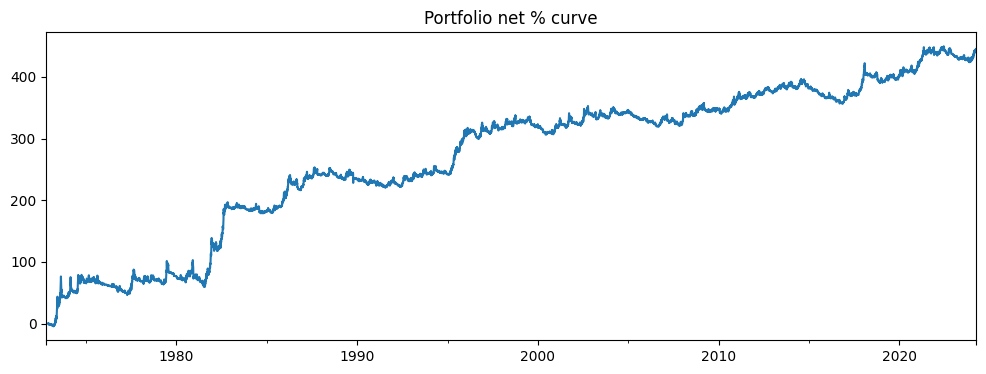

In [29]:
print("=== 净收益 ===");  print("Sharpe:", profits.percent.sharpe())
print("=== 毛收益 ===");  print("Sharpe:", profits.gross.percent.sharpe())
print("=== 成本拖累（年化） ===");  print("ann_mean:", profits.costs.percent.ann_mean())

profits.percent.curve().plot(figsize=(12, 4), title="Portfolio net % curve")

### 实验：加法口径 vs 复利口径——杠杆的代价在哪显形？

`percent.curve()` 是**加法累计**（固定名义本金，盈亏不滚入），这种口径下所有风险调整比率对杠杆免疫：vol target 翻倍，Sharpe/Calmar 原地不动，只有绝对幅度（min/max、回撤深度、成本拖累）按比例放大。

但如果盈亏**滚入本金**（更接近真实账户），日收益就要相乘。此时出现不对称性：跌 50% 需要涨 100% 才回本，波动本身开始消耗复合增长。几何增长近似 $g \approx \mu - \sigma^2/2$——$\mu$ 随杠杆线性涨，$\sigma^2$ 随杠杆**平方**涨，因此复合增长必然存在最优点（Kelly 的影子）。

下面把 vt=15 / 25 / 50 的日收益分别按加法、乘法两种方式累计，对比 CAGR 与复合口径最大回撤。先预测：vt=50 的复合 CAGR 会是 vt=15 的 3.33 倍吗？


2026-09-14 22:44:35 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:44:35 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:44:35 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:44:35 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-09-14 22:44:35 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-09-14 22:44:35 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2026-09-14 22:44:35 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2026-09-14 22:44:35 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating instrument weights
2026-09-14 22:44:35 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN

C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\1770486067.py:38: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\1770486067.py:38: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\1770486067.py:38: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\1770486067.py:38: UserWarning: Glyph 22266 (\N{CJK UNIFIED IDEOGRAPH-56FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\1770486067.py:38: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\1770486067.py:38: UserWarning: Glyph 26

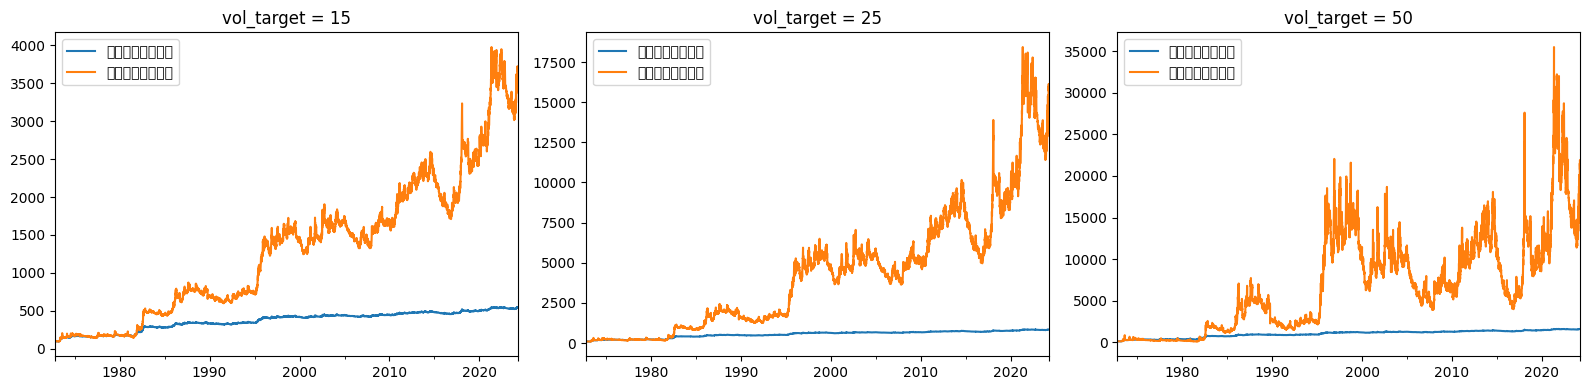

In [30]:
# 对三个 vol target 分别重建系统，取净收益日序列，做加法/乘法两种累计对比
# 注意：每次必须重建 System，否则缓存里的旧结果不会刷新
import matplotlib.pyplot as plt

rows = []
nav_curves = {}
for vt in [15, 25, 50]:
    my_config.percentage_vol_target = vt
    s = System([fcs, empty_rules, combiner, position_size, raw_data, portfolio, accounts],
               data, my_config)
    r = s.accounts.portfolio().percent  # 净收益，日频率，单位：百分点
    r_series = pd.Series(r)             # 转成普通 Series 方便 cumsum/cumprod

    nav_add = 100 + r_series.cumsum()               # 加法口径：固定本金
    nav_mul = 100 * (1 + r_series / 100).cumprod()  # 复利口径：盈亏滚入本金
    nav_curves[vt] = (nav_add, nav_mul)

    n_years = len(r_series) / 256
    cagr_add = (nav_add.iloc[-1] / 100) ** (1 / n_years) - 1
    cagr_mul = (nav_mul.iloc[-1] / 100) ** (1 / n_years) - 1
    dd_mul = (nav_mul / nav_mul.cummax() - 1).min()  # 复利口径最大回撤
    rows.append(dict(vol_target=vt,
                     CAGR_加法=cagr_add, CAGR_复利=cagr_mul,
                     最大回撤_复利=dd_mul))

cmp_df = pd.DataFrame(rows).set_index("vol_target")
cmp_df["复利CAGR倍数_vs_vt15"] = cmp_df["CAGR_复利"] / cmp_df.loc[15, "CAGR_复利"]
print(cmp_df.to_string(float_format=lambda x: f"{x:.3f}"))
print("\n检验：若杠杆免费，vt=50 的复利CAGR ≈ vt=15 的 3.3 倍；实际倍数越小，说明波动惩罚越大")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, vt in zip(axes, [15, 25, 50]):
    nav_add, nav_mul = nav_curves[vt]
    nav_add.plot(ax=ax, label="加法（固定本金）")
    nav_mul.plot(ax=ax, label="复利（滚入本金）")
    ax.set_title(f"vol_target = {vt}")
    ax.legend()
plt.tight_layout()

<a id="s13"></a>
## 13. 使用预构建系统 simplesystem 与 futures_system

实际使用中**不会**手动拼装阶段，而是用预烘焙 (pre-baked) 入口函数，再按需替换 `data` 和 `config`：

- `simplesystem()`：对应前面手动搭建的例子，配置来自 `systems/provided/example/simplesystemconfig.yaml`
- `futures_system()`（`futures_chapter15`）：书中第 15 章的完整系统，分 `basesystem`（固定参数，快）和 `estimatedsystem`（滚动估计，慢）两个版本

[↑ 回概念地图](#map)


### 预烘焙系统：chapter15 basesystem 实测

与 minimal 系统同一骨架（7 stage），差异全在 config：6 条 ewmac 速度谱 + carry（权重 0.50）、6 品种、vt=20%、IDM 1.89 / FDM 1.31。

先看数字，再看曲线形状。

In [31]:
import pandas as pd
from systems.provided.futures_chapter15.basesystem import futures_system

base_sys = futures_system()   # CSV 模拟数据 + futuresconfig.yaml，全默认
base_pandl = base_sys.accounts.portfolio()
base_r = pd.Series(base_pandl.percent)   # 日收益（% of notional capital）

# 关键统计（net，加法口径）。注意 stats() 返回 [键值对列表, 注释]，取 [0] 即可
base_stats = dict(base_pandl.percent.stats()[0])
for k in ['ann_mean', 'ann_std', 'sharpe', 'avg_drawdown', 'time_in_drawdown', 'calmar', 'hitrate']:
    print(f"{k:>20s}: {base_stats[k]}")

2026-09-14 22:45:17 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:45:17 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:45:17 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:45:17 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-09-14 22:45:17 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-09-14 22:45:17 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2026-09-14 22:45:17 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2026-09-14 22:45:17 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating instrument weights
2026-09-14 22:45:17 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN

C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\603360921.py:24: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\603360921.py:24: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\603360921.py:24: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\603360921.py:24: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\603360921.py:24: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\603360921.py:24: UserWarning: Glyph 22797 (\N{CJK UNIFI

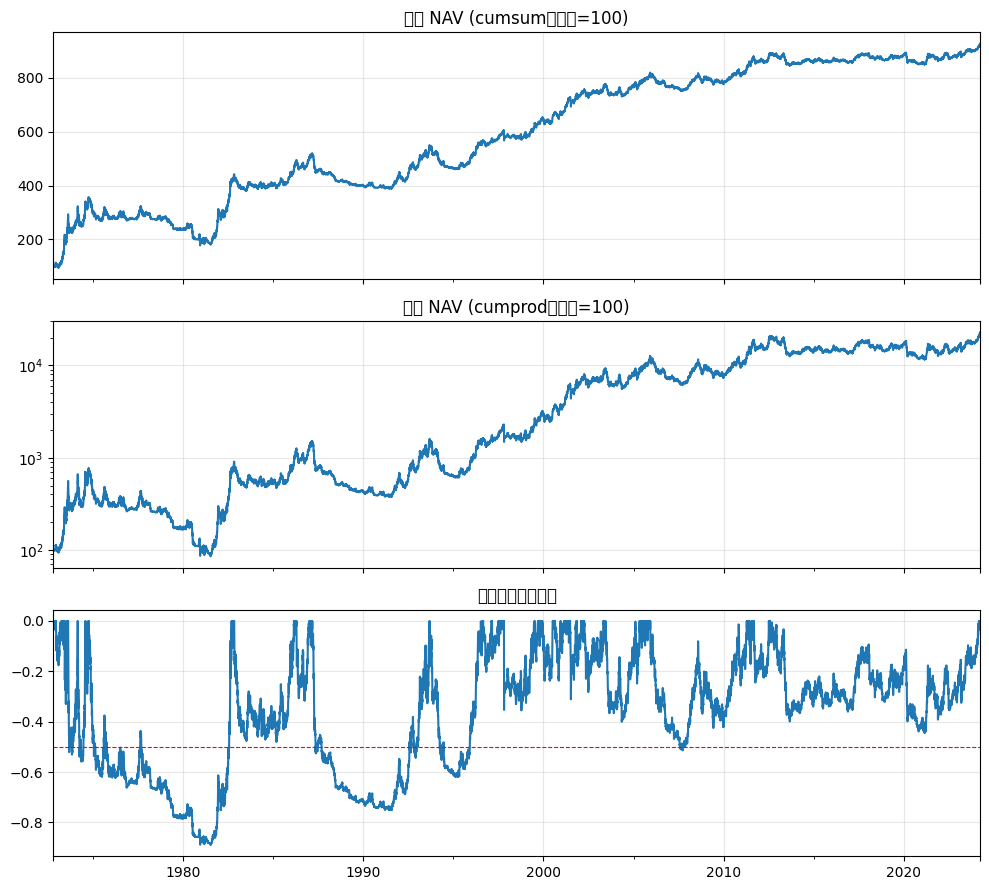

In [32]:
# 三条曲线：加法 NAV、复利 NAV、回撤
# 防御：内核重启后若 base_r 不存在，自动重建 basesystem（秒级）
import pandas as pd
import matplotlib.pyplot as plt

if 'base_r' not in dir():
    from systems.provided.futures_chapter15.basesystem import futures_system
    base_sys = futures_system()
    base_pandl = base_sys.accounts.portfolio()
    base_r = pd.Series(base_pandl.percent)
    base_stats = dict(base_pandl.percent.stats()[0])

base_nav_add = 100 + base_r.cumsum()
base_nav_mul = 100 * (1 + base_r / 100).cumprod()
base_dd = base_nav_mul / base_nav_mul.cummax() - 1

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
base_nav_add.plot(ax=axes[0], title='加法 NAV (cumsum，基期=100)')
base_nav_mul.plot(ax=axes[1], title='复利 NAV (cumprod，基期=100)', logy=True)
base_dd.plot(ax=axes[2], title='回撤（复利口径）')
axes[2].axhline(-0.5, color='r', ls='--', lw=0.8)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### basesystem vs minimal 系统直接对比

minimal 系统（4 品种 / 2 条 ewmac / vt=25，内核现存变量 `profits`）vs basesystem（6 品种 / ewmac 谱 + carry 半仓 / vt=20）。

先想再跑：basesystem 的分散化几乎翻倍（IDM 1.89 vs 1.5，品种 6 vs 4），Sharpe 应该明显更高吗？

In [33]:
# 公平对比：把 minimal 系统重建为 vt=20，与 basesystem 同杠杆
# （config 改动必须重建 System，缓存的旧结果不会刷新）
# 本格自包含：内核重启后可直接运行；basesystem 便宜会自动重建
import pandas as pd
from sysdata.config.configdata import Config
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
from systems.basesystem import System
from systems.forecasting import Rules
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecast_combine import ForecastCombine
from systems.rawdata import RawData
from systems.positionsizing import PositionSizing
from systems.portfolio import Portfolios
from systems.accounts.accounts_stage import Account
from systems.trading_rules import TradingRule
from systems.provided.rules.ewmac import ewmac_forecast_with_defaults as ewmac_func

data = csvFuturesSimData()

# 复现 §5–§11 的 minimal config（唯一改动：vt=20）
my_config = Config()
my_config.trading_rules = dict(
    ewmac8=TradingRule((ewmac_func, [], dict(Lfast=8, Lslow=32))),
    ewmac32=TradingRule(dict(function=ewmac_func, other_args=dict(Lfast=32, Lslow=128))),
)
my_config.instruments = ["SOFR", "US10", "CORN", "SP500_micro"]
my_config.use_forecast_scale_estimates = False
my_config.forecast_scalars = dict(ewmac8=5.3, ewmac32=2.65)
my_config.use_forecast_weight_estimates = False
my_config.forecast_weights = dict(ewmac8=0.5, ewmac32=0.5)
my_config.use_forecast_div_mult_estimates = False
my_config.forecast_div_multiplier = 1.1
my_config.percentage_vol_target = 20
my_config.notional_trading_capital = 500000
my_config.base_currency = "GBP"
my_config.use_instrument_weight_estimates = False
my_config.instrument_weights = dict(US10=.1, SOFR=.4, CORN=.3, SP500_micro=.8)
my_config.use_instrument_div_mult_estimates = False
my_config.instrument_div_multiplier = 1.5

mini_sys20 = System([ForecastScaleCap(), Rules(), ForecastCombine(), PositionSizing(),
                     RawData(), Portfolios(), Account()], data, my_config)
mini_pandl20 = mini_sys20.accounts.portfolio()
mini_r20 = pd.Series(mini_pandl20.percent)

# 防御：若内核重启导致 base 变量丢失，自动重建（秒级）
if 'base_stats' not in dir():
    from systems.provided.futures_chapter15.basesystem import futures_system
    base_sys = futures_system()
    base_pandl = base_sys.accounts.portfolio()
    base_r = pd.Series(base_pandl.percent)
    base_stats = dict(base_pandl.percent.stats()[0])

mini_stats20 = dict(mini_pandl20.percent.stats()[0])
keys = ['ann_mean', 'ann_std', 'sharpe', 'sortino', 'avg_drawdown',
        'time_in_drawdown', 'calmar', 'hitrate', 'profitfactor', 't_stat']

cmp_stats = pd.DataFrame({
    'minimal(4品种,2 ewmac)': {k: mini_stats20[k] for k in keys},
    'basesystem(6品种,ewmac谱+carry)': {k: base_stats[k] for k in keys},
}).astype(float)
print("=== 两系统均为 vt=20，全部指标可直接对比 ===")
print(cmp_stats.to_string(float_format=lambda x: f"{x:.3f}"))

2026-09-14 22:45:37 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:45:37 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:45:37 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:45:37 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-09-14 22:45:37 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-09-14 22:45:37 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2026-09-14 22:45:37 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2026-09-14 22:45:37 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating instrument weights
2026-09-14 22:45:37 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN

C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3079178560.py:23: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3079178560.py:23: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3079178560.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3079178560.py:23: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3079178560.py:23: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3079178560.py:23: UserWarning: Glyph 6

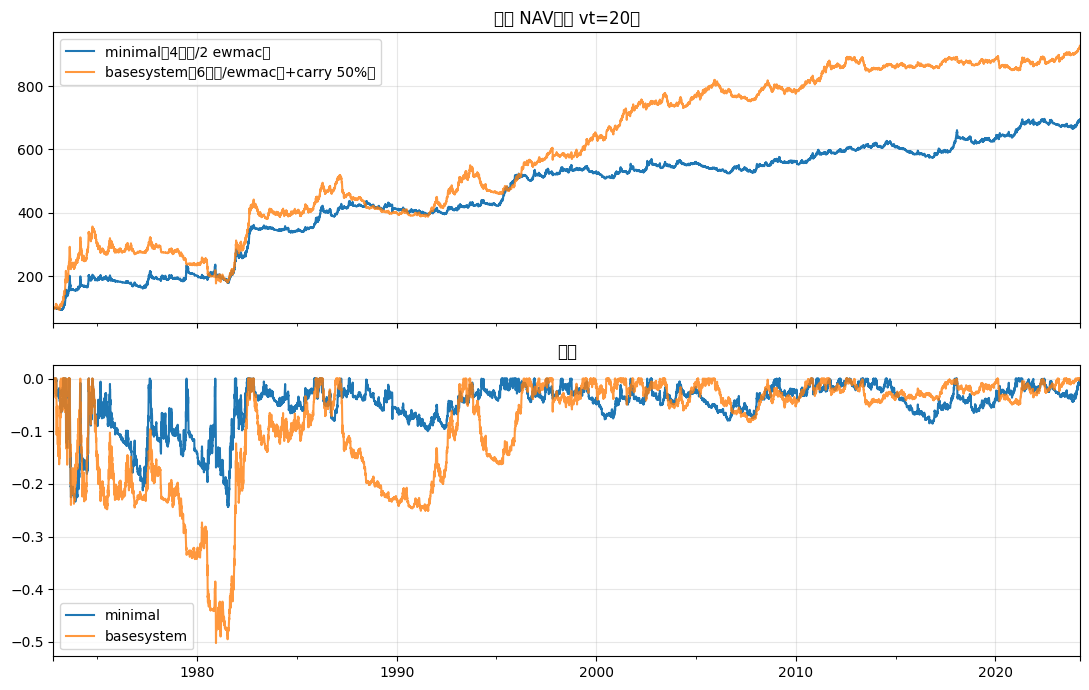


日收益相关系数: 0.498


In [34]:
# 曲线对比（同 vt=20，无需再缩放）：加法 NAV + 回撤
# 依赖：mini_r20、base_r（上方 cell 已自包含，若此处报 NameError 先跑上方 minimal 对比格）
import pandas as pd
import matplotlib.pyplot as plt

if 'mini_r20' not in dir() or 'base_r' not in dir():
    raise NameError("缺少 mini_r20 或 base_r：请先运行上方的 minimal 对比格（第 53 格）")

mini_nav20 = 100 + mini_r20.cumsum()
base_nav = 100 + base_r.cumsum()
mini_dd20 = mini_nav20 / mini_nav20.cummax() - 1
base_dd20 = base_nav / base_nav.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
mini_nav20.plot(ax=axes[0], label='minimal（4品种/2 ewmac）')
base_nav.plot(ax=axes[0], label='basesystem（6品种/ewmac谱+carry 50%）', alpha=0.8)
axes[0].set_title('加法 NAV（同 vt=20）')
axes[0].legend(); axes[0].grid(alpha=0.3)

mini_dd20.plot(ax=axes[1], label='minimal')
base_dd20.plot(ax=axes[1], label='basesystem', alpha=0.8)
axes[1].set_title('回撤'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 两系统日收益的相关性：多高才算"另一个系统"？
common = pd.concat([mini_r20, base_r], axis=1, keys=['mini', 'base']).dropna()
print(f"\n日收益相关系数: {common.corr().iloc[0,1]:.3f}")

### basesystem vs estimatedsystem：手调参数 vs 滚动估计

同一骨架、同 6 品种、同 vt=20，唯一差异：**参数是固定的还是估出来的**。

estimatedsystem 的 config 打开了全部估计开关：
- forecast scalars（跨品种池化）
- forecast weights + FDM（`rule_variations` 限制只用 4 条规则：ewmac16_64/32_128/64_256/carry——恰是 base 里非零权重的那 4 条）
- instrument weights + IDM

估计方式：扩展窗口（expanding）、样本外、日频滚动。运行成本：首次组合盈亏约 60s（base 秒出）——这就是 §14 缓存存在的理由。

预测：估计版应该更差还是更好？考虑两个方向相反的力量——样本外权重适应性 vs 估计噪声。

In [35]:
# estimatedsystem：首次运行约 60s（权重/乘数全部日频滚动估计）
# 跑完建议顺手 pickle 缓存，下次秒开
import time
import pandas as pd
from systems.provided.futures_chapter15.estimatedsystem import futures_system as est_futures_system

# 防御：basesystem 变量若丢失则自动重建（秒级）
if 'base_stats' not in dir():
    from systems.provided.futures_chapter15.basesystem import futures_system
    base_sys = futures_system()
    base_pandl = base_sys.accounts.portfolio()
    base_r = pd.Series(base_pandl.percent)
    base_stats = dict(base_pandl.percent.stats()[0])

t0 = time.time()
est_sys = est_futures_system()
est_pandl = est_sys.accounts.portfolio()
est_r = pd.Series(est_pandl.percent)
print(f"首次计算耗时: {time.time()-t0:.0f}s")

est_stats = dict(est_pandl.percent.stats()[0])
keys = ['ann_mean', 'ann_std', 'sharpe', 'sortino', 'avg_drawdown',
        'time_in_drawdown', 'calmar', 'hitrate', 'profitfactor', 't_stat']
cmp_be = pd.DataFrame({
    'base（手调固定）': {k: base_stats[k] for k in keys},
    'estimated（滚动估计）': {k: est_stats[k] for k in keys},
}).astype(float)
print(cmp_be.to_string(float_format=lambda x: f"{x:.3f}"))

2026-09-14 22:45:51 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:45:51 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:45:51 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:45:51 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-09-14 22:45:51 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-09-14 22:45:51 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2026-09-14 22:45:51 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2026-09-14 22:45:51 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating instrument weights
2026-09-14 22:45:51 DEBUG base_system Following instruments are 'duplicate_markets' [

C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3912263591.py:26: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3912263591.py:26: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3912263591.py:26: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3912263591.py:26: UserWarning: Glyph 22266 (\N{CJK UNIFIED IDEOGRAPH-56FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3912263591.py:26: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_3460\3912263591.py:26: UserWarning: Glyph 21

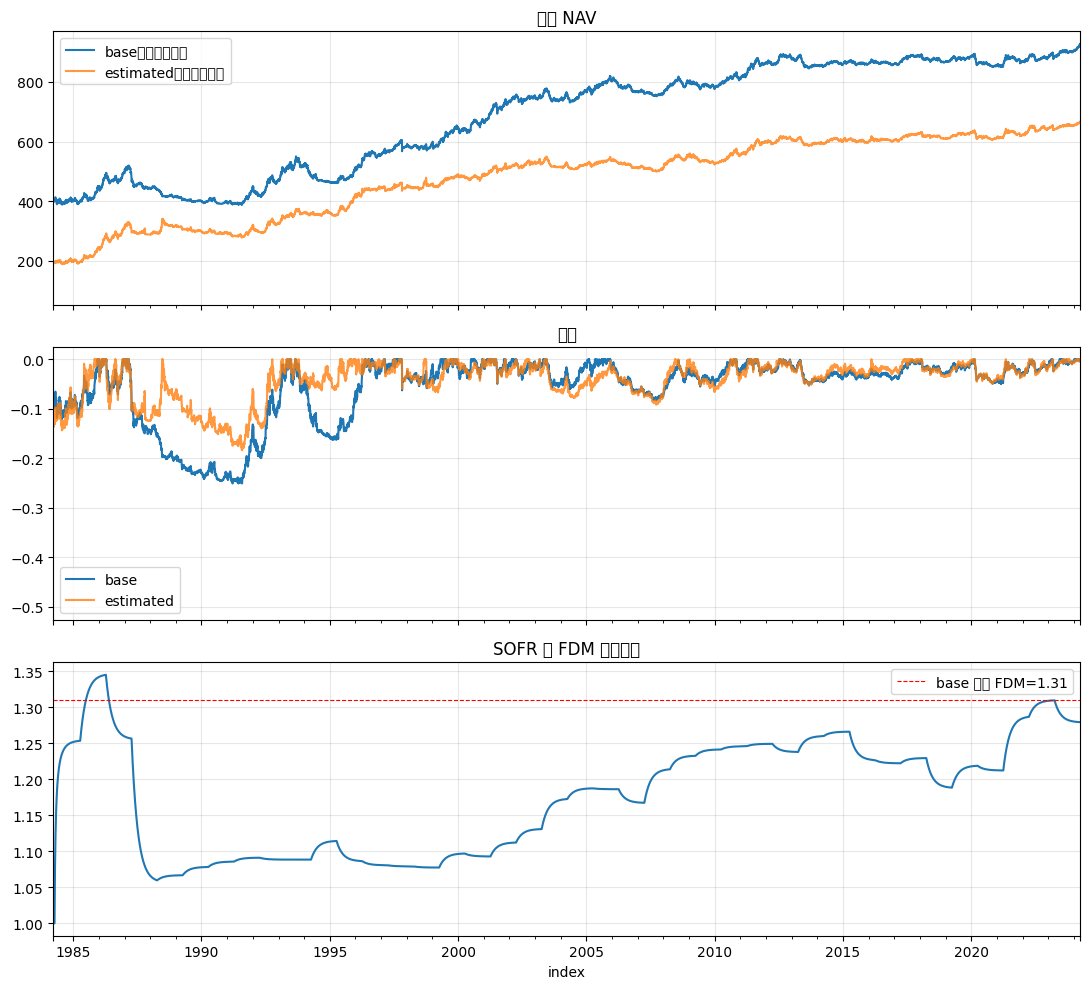

日收益相关系数: 0.828


In [36]:
# 曲线 + 时变参数：估计系统真正有趣的不是绩效，是参数的时间序列
# 依赖：est_r、base_r、est_sys（若报 NameError，先跑上方 estimated 运行格；该格约 60s）
import pandas as pd
import matplotlib.pyplot as plt

if 'est_r' not in dir() or 'base_r' not in dir() or 'est_sys' not in dir():
    raise NameError("缺少 est_r / base_r / est_sys：请先运行上方 estimated 运行格（约 60s）")

est_nav = 100 + est_r.cumsum()
est_dd = est_nav / est_nav.cummax() - 1
base_nav = 100 + base_r.cumsum()
base_dd20 = base_nav / base_nav.cummax() - 1

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
base_nav.plot(ax=axes[0], label='base（固定参数）')
est_nav.plot(ax=axes[0], label='estimated（滚动估计）', alpha=0.8)
axes[0].set_title('加法 NAV'); axes[0].legend(); axes[0].grid(alpha=0.3)

base_dd20.plot(ax=axes[1], label='base'); est_dd.plot(ax=axes[1], label='estimated', alpha=0.8)
axes[1].set_title('回撤'); axes[1].legend(); axes[1].grid(alpha=0.3)

# FDM 时间序列：估计版 FDM 是时变的（base 恒为 1.31）
est_sys.combForecast.get_forecast_diversification_multiplier("SOFR").plot(ax=axes[2])
axes[2].axhline(1.31, color='r', ls='--', lw=0.8, label='base 固定 FDM=1.31')
axes[2].set_title('SOFR 的 FDM 时间序列'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

common2 = pd.concat([base_r, est_r], axis=1, keys=['base', 'est']).dropna()
print(f"日收益相关系数: {common2.corr().iloc[0,1]:.3f}")

base 起点: 1972-10-18 00:00:00  estimated 起点: 1972-10-18 00:00:00
           ann_mean  ann_std  sharpe  n_years  sharpe_全样本_base参照
base         15.719   32.874   0.478   52.430              0.478
estimated    10.766   20.818   0.517   52.430                NaN


d:\dev\pysystemtrade\.venv-py312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\dev\pysystemtrade\.venv-py312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\dev\pysystemtrade\.venv-py312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\dev\pysystemtrade\.venv-py312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\dev\pysystemtrade\.venv-py312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) mi

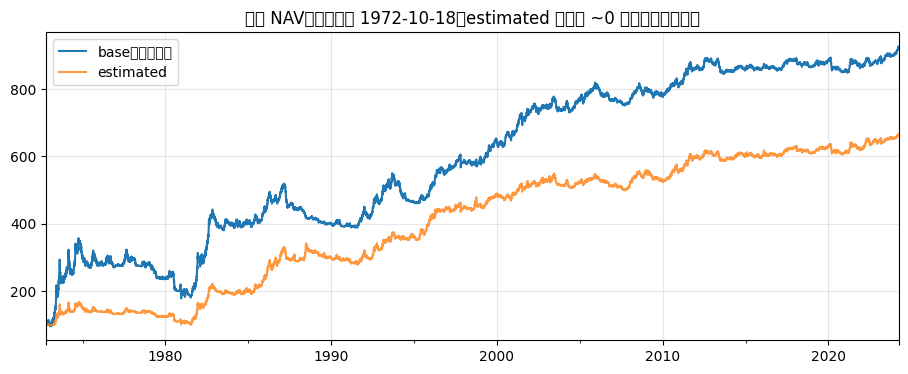

In [37]:
# 起点差异检查 + 截齐样本后的公平对比
# 依赖：est_r、base_r、base_stats（若报 NameError，先跑上方 estimated 运行格）
import pandas as pd
import matplotlib.pyplot as plt

if 'est_r' not in dir() or 'base_r' not in dir():
    raise NameError("缺少 est_r / base_r：请先运行上方 estimated 运行格（约 60s）")

print("base 起点:", base_r.first_valid_index(), " estimated 起点:", est_r.first_valid_index())

t0 = est_r.first_valid_index()   # 以估计版起点为公共起点
base_r_aligned = base_r[t0:]
est_r_aligned = est_r[t0:]

# 截齐后的 stats（手动算核心几项，避免再造 accountCurve）
def quick_stats(r):
    return dict(ann_mean=r.mean()*256, ann_std=r.std()*16,
                sharpe=r.mean()/r.std()*16, n_years=len(r)/256)

al = pd.DataFrame({'base': quick_stats(base_r_aligned),
                   'estimated': quick_stats(est_r_aligned)}).T
if 'base_stats' in dir():
    al['sharpe_全样本_base参照'] = [float(base_stats['sharpe']), None]
print(al.to_string(float_format=lambda x: f"{x:.3f}"))

# 截齐后的 NAV 对比
fig, ax = plt.subplots(figsize=(11, 4))
(100 + base_r_aligned.cumsum()).plot(ax=ax, label='base（截齐后）')
(100 + est_r_aligned.cumsum()).plot(ax=ax, label='estimated', alpha=0.8)
ax.set_title(f'加法 NAV，统一起点 {t0.date()}（estimated 热身期 ~{len(base_r)-len(base_r_aligned)} 个交易日被剔除）')
ax.legend(); ax.grid(alpha=0.3); plt.show()

In [38]:
from systems.provided.example.simplesystem import simplesystem

my_system = simplesystem()
print(my_system)
my_system.portfolio.get_notional_position("SOFR").tail(5)

System base_system with .config, .data, and .stages: accounts, portfolio, positionSize, combForecast, forecastScaleCap, rules, rawdata
2026-09-14 22:46:55 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:46:55 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:46:55 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:46:55 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating notional position for SOFR
2026-09-14 22:46:55 INFO base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating instrument weights
2026-09-14 22:46:55 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'SOFR'} Calculating raw instrument weights
2026-09-14 22:46:55 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:

index
2024-03-22   -10.701093
2024-03-25   -10.224163
2024-03-26    -9.492612
2024-03-27    -7.597249
2024-03-28    -6.606060
Freq: B, dtype: float64

In [39]:
# 传入自定义 config / data 的标准姿势（这是绝大多数时候创建系统的方式）
my_config = Config("systems.provided.example.simplesystemconfig.yaml")
my_data = csvFuturesSimData()
# ... 在这里按需修改 my_config / my_data ...
my_system = simplesystem(config=my_config, data=my_data)

# 完整的 chapter 15 系统（固定参数版，运行快）
from systems.provided.futures_chapter15.basesystem import futures_system
system = futures_system()
system.portfolio.get_notional_position("EUROSTX").tail(5)

2026-09-14 22:47:03 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:47:03 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:47:03 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:47:03 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'EUROSTX'} Calculating notional position for EUROSTX
2026-09-14 22:47:03 INFO base_system {'stage': 'portfolio', 'instrument_code': 'EUROSTX'} Calculating instrument weights
2026-09-14 22:47:03 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'EUROSTX'} Calculating raw instrument weights
2026-09-14 22:47:03 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:47:03 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:4

index
2024-03-22    5.122159
2024-03-25    5.285780
2024-03-26    5.385521
2024-03-27    5.451916
2024-03-28    5.518672
Freq: B, dtype: float64

<a id="s14"></a>
## 14. 缓存系统计算结果（cache pickle/unpickle）

估计版系统（`estimatedsystem`）运行很慢。系统的中间计算结果都缓存在 `system.cache` 中，可以 pickle 到磁盘、跨会话复用：

```python
# 第一次（慢）：运行并保存缓存（路径相对项目根解析，见下方说明）
system.cache.pickle("project/data/cache/this_system_name.pck")

# 新会话：恢复缓存后，统计计算飞快
system.cache.unpickle("project/data/cache/this_system_name.pck")
system.accounts.portfolio().sharpe()
```

> **路径解析说明**：`cache.pickle/unpickle` 内部用 `syscore.fileutils.resolve_path_and_filename_for_package` 解析路径，**相对路径以项目根（`d:\dev\pysystemtrade`）为基准**；而 Python 标准库 `os.remove` 等以当前工作目录（CWD）为基准。混用两者容易在 Notebook（CWD 为 notebook 所在目录）中报 `FileNotFoundError`。稳妥做法：用 `resolve_path_and_filename_for_package` 拿到绝对路径后再做文件操作。
>
> 本项目的 AI/用户共产统一放在 `project/` 下，学习/demo 缓存按约定放 `project/data/cache/`（与原项目"缓存单独放 `private/`"的取舍一致，与运维证据 `maintenance/` 区分）。

> 下面这个 cell 演示机制（为避免长时间计算，只展示 pickle/unpickle 流程，不实际跑 estimatedsystem 的完整估计）。

[↑ 回概念地图](#map)

---

## 学习路径总结与下一步

✅ 已完成：数据对象 → 单规则 → 盈亏 → 逐阶段构建完整系统 → 预烘焙系统 → 缓存

**下一步建议**：
1. 阅读 `docs/backtesting.md`（完整用户指南：默认值文件、成本模型、优化方法等）
2. 对照 `systems/provided/futures_chapter15/futuresconfig.yaml` 理解生产级配置
3. 深入源码：`systems/basesystem.py`（System 类与缓存机制）、`systems/stage.py`（阶段基类）
4. 之后再看生产环节：`sysproduction/`（数据更新、执行、风控）与 `sysbrokers/IB/`（IB 对接）


In [40]:
# 缓存机制演示：basesystem 也有 cache；estimatedsystem 才真正需要它
# 注意：cache.pickle/unpickle 通过 resolve_path_and_filename_for_package 解析路径，
# 相对路径以项目根（d:\dev\pysystemtrade）为基准；而 os.remove 以 CWD 为基准。
# 因此统一用 resolve_path_and_filename_for_package 得到绝对路径，保证两边一致。
import os
from syscore.fileutils import resolve_path_and_filename_for_package

cache_file = "project/data/cache/learning_demo_cache.pck"  # 项目根相对路径
full_path = resolve_path_and_filename_for_package(cache_file)
os.makedirs(os.path.dirname(full_path), exist_ok=True)

system = futures_system()
system.accounts.portfolio().sharpe()   # 触发一些计算，填充缓存
system.cache.pickle(cache_file)        # 保存缓存
print("缓存已写入:", full_path)
print("cache keys 示例:", list(system.cache.keys())[:5], "...")

# 模拟新会话：重建系统并恢复缓存
system2 = futures_system()
system2.cache.unpickle(cache_file)
print("恢复后 sharpe（秒出）:", system2.accounts.portfolio().sharpe())

# 清理演示文件（同一基准，不会因 CWD 不同而找不到）
if os.path.exists(full_path):
    os.remove(full_path)
    print("演示缓存已清理:", full_path)


2026-09-14 22:47:18 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-14 22:47:18 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-14 22:47:18 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-14 22:47:18 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-09-14 22:47:18 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-09-14 22:47:18 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2026-09-14 22:47:18 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2026-09-14 22:47:18 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating instrument weights
2026-09-14 22:47:18 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN